# Membership-Signal Analysis (Forget vs Retain)

This notebook loads a `membership_*.json` file produced by `run_lunar.py` and generates:
- KDE + histogram overlays
- ECDF curves
- Violin + box plots
- ROC/AUC for each metric

It also prints the two-sample test statistics already computed.

Note: by default, LUNAR evaluates at most 200 examples per split. Increase the cap in `src/eval_util.py` if you need stronger statistical power.


In [19]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, auc

file_path = '/nfs-share/ahta3/workspace/LUNAR/unlearn_results/completions/llama2-7b-chat/lunar/pistol_sample1/data_extraction/Trial1/membership_22.json'

In [ ]:
with open(file_path, 'r') as f:
    data = json.load(f)

forget = data['forget_metrics']
retain = data['retain_metrics']
tests = data['tests']


In [ ]:
# Print two-sample test summary
pd.set_option('display.max_colwidth', None)
summary = pd.DataFrame(tests).T
summary


,forget_mean,retain_mean,mean_diff,ks_stat,ks_pvalue,mw_stat,mw_pvalue,tt_stat,tt_pvalue
nll,9.817578,1.039218,8.778360,0.850,9.923421e-15,3842.5,1.147564e-11,7.411739,3.688296e-07
nll_per_token,1.784180,0.120027,1.664153,0.945,1.422769e-20,3953.5,6.217124e-13,11.373954,3.831509e-10
entropy,1.354688,0.128212,1.226475,0.880,3.201340e-16,3908.0,2.095333e-12,8.262342,8.339985e-08
max_prob,0.770117,0.974883,-0.204766,0.865,1.891610e-15,110.0,3.375492e-13,-9.611850,6.266555e-09


In [27]:
metrics = ['nll', 'nll_per_token', 'entropy', 'max_prob']

def plot_kde_hist(ax, f, r, title, xlabel):
    f = np.asarray(f)
    r = np.asarray(r)
    bins = 30
    ax.hist(r, bins=bins, density=True, alpha=0.25, label='retain')
    ax.hist(f, bins=bins, density=True, alpha=0.25, label='forget')

    for arr, color, label in [(r, 'C0', 'retain'), (f, 'C1', 'forget')]:
        if len(arr) > 1 and np.std(arr) > 0:
            kde = gaussian_kde(arr)
            xs = np.linspace(np.min(arr), np.max(arr), 200)
            ax.plot(xs, kde(xs), color=color, lw=2, label=f'{label} KDE')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

def plot_ecdf(ax, f, r, title, xlabel):
    def ecdf(x):
        x = np.sort(x)
        y = np.arange(1, len(x)+1) / len(x)
        return x, y

    xf, yf = ecdf(np.asarray(f))
    xr, yr = ecdf(np.asarray(r))
    ax.plot(xr, yr, label='retain')
    ax.plot(xf, yf, label='forget')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('ECDF')
    ax.legend()

def plot_violin_box(ax, f, r, title, ylabel):
    data = [r, f]
    ax.violinplot(data, showmeans=False, showmedians=True)
    ax.boxplot(data, widths=0.2, positions=[1, 2])
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['retain', 'forget'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)


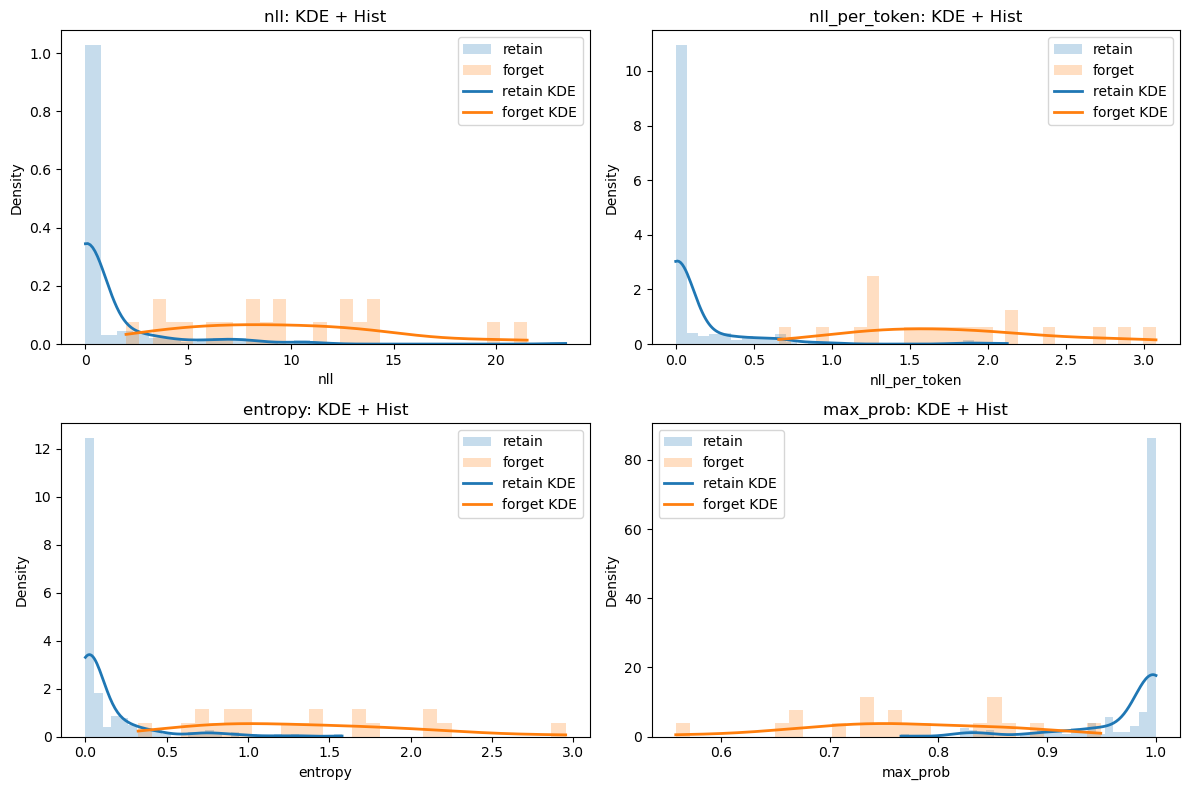

In [28]:
# KDE + histogram overlays
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.flatten(), metrics):
    plot_kde_hist(ax, forget[m], retain[m], f'{m}: KDE + Hist', m)
plt.tight_layout()
plt.show()


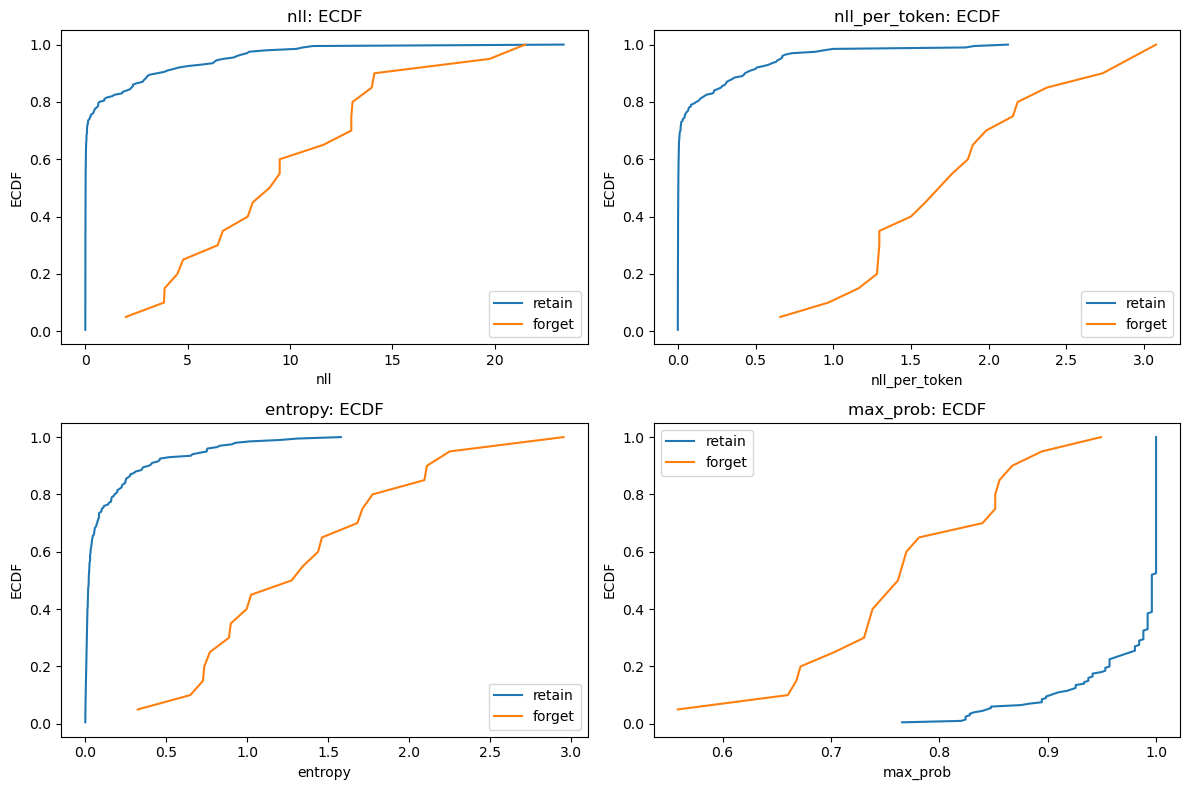

In [29]:
# ECDF curves (useful for KS test intuition)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.flatten(), metrics):
    plot_ecdf(ax, forget[m], retain[m], f'{m}: ECDF', m)
plt.tight_layout()
plt.show()


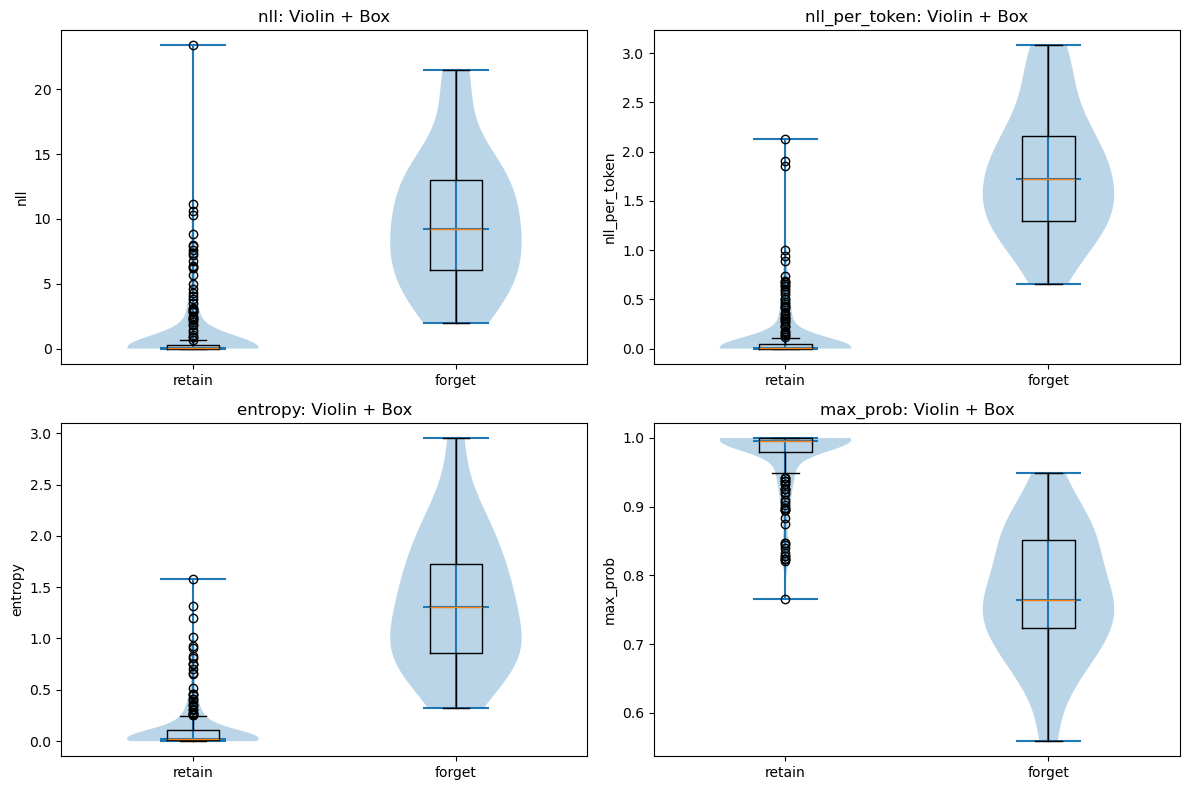

In [30]:
# Violin + box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.flatten(), metrics):
    plot_violin_box(ax, forget[m], retain[m], f'{m}: Violin + Box', m)
plt.tight_layout()
plt.show()


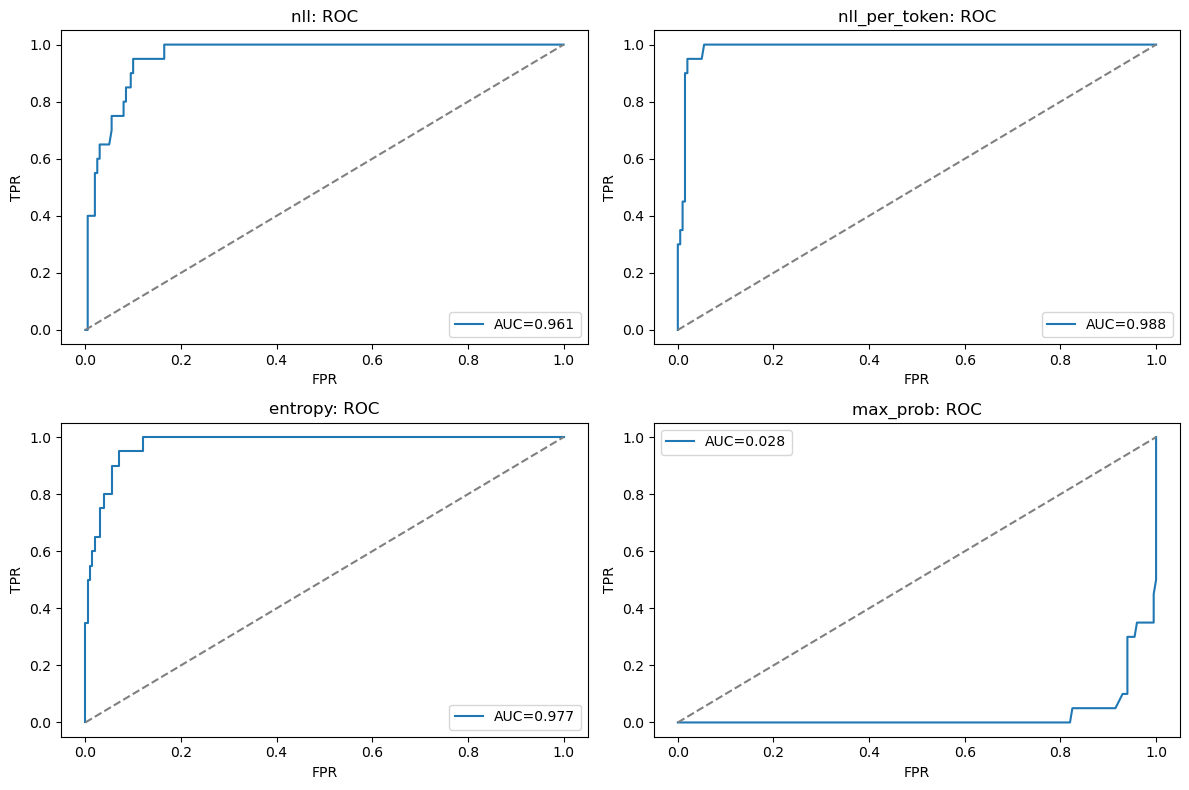

,metric,auc
1,nll_per_token,0.988375
2,entropy,0.977000
0,nll,0.960625
3,max_prob,0.027500


In [26]:
# ROC/AUC for each metric
# We treat forget as positive class (label=1)
rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, m in zip(axes.flatten(), metrics):
    f = np.asarray(forget[m])
    r = np.asarray(retain[m])
    y = np.concatenate([np.zeros_like(r), np.ones_like(f)])
    scores = np.concatenate([r, f])

    # For some metrics, higher means more likely forget; for others, invert
    # We will use raw scores and also report AUC; you can flip if desired.
    fpr, tpr, _ = roc_curve(y, scores)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
    ax.plot([0,1], [0,1], '--', color='gray')
    ax.set_title(f'{m}: ROC')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

    rows.append({'metric': m, 'auc': roc_auc})

plt.tight_layout()
plt.show()

pd.DataFrame(rows).sort_values('auc', ascending=False)


## Interpreting the plots
- For **NLL** and **entropy**, you generally expect **forget > retain** if unlearning succeeded.
- For **max_prob**, you generally expect **forget < retain** if unlearning succeeded.
- Clear separation in KDE/ECDF + AUC > 0.7 suggests the metric can distinguish forget vs retain.
- If separation is weak, either unlearning was weak or the metric is too noisy for this data.
